In [1]:
using Flux
using Plots
using Random
using Turing

Turing.turnprogress(false)
Turing.setadbackend(:reversediff)

LoadError: UndefVarError: turnprogress not defined

In [2]:
N = 100
M = round(Int, N / 4)
Random.seed!(8844);

In [3]:
x1s = rand(M) * 4.5
x2s = rand(M) * 4.5
xt1s = Array([[x1s[i] + 0.5; x2s[i] + 0.5] for i = 1:M])

x1s = rand(M) * 4.5
x2s = rand(M) * 4.5
append!(xt1s, Array([[x1s[i] - 5; x2s[i] - 5] for i = 1:M]));

In [4]:
x1s = rand(M) * 4.5
x2s = rand(M) * 4.5
xt0s = Array([[x1s[i] + 0.5; x2s[i] - 5] for i = 1:M])

x1s = rand(M) * 4.5
x2s = rand(M) * 4.5
append!(xt0s, Array([[x1s[i] - 5; x2s[i] + 0.5] for i = 1:M]));

In [5]:
X = [xt1s; xt0s]
y = [ones(2 * M); zeros(2 * M)];

In [6]:
function plotdata()
    x1 = map(e -> e[1], xt1s)    
    y1 = map(e -> e[2], xt1s)
    x2 = map(e -> e[1], xt0s)
    y2 = map(e -> e[2], xt0s)
    Plots.scatter(x1, y1, color="red", clim=(0, 1))
    Plots.scatter!(x2, y2, color="blue", clim=(0, 1))
end

plotdata (generic function with 1 method)

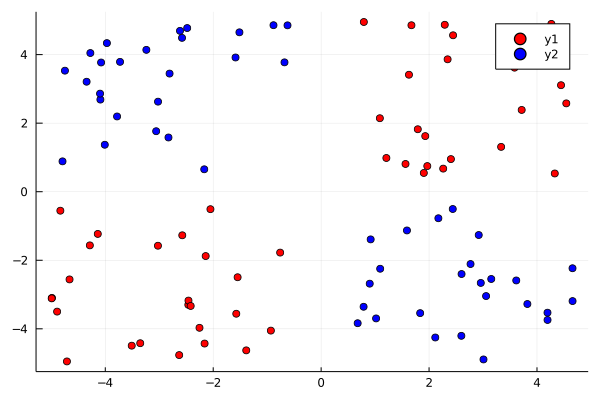

In [7]:
plotdata()

In [8]:
function unpackparams(nnparams::AbstractVector)
    W1 = reshape(nnparams[1:6], 3, 2)
    b1 = reshape(nnparams[7:9], 3)
    W2 = reshape(nnparams[10:15], 2, 3)
    b2 = reshape(nnparams[16:17], 2)
    W0 = reshape(nnparams[18:19], 1, 2)
    b0 = reshape(nnparams[20:20], 1)
    W1, b1, W2, b2, W0, b0
end

unpackparams (generic function with 1 method)

In [9]:
function forwardpass(X, nnparams::AbstractVector)
    W1, b1, W2, b2, W0, b0 = unpackparams(nnparams)
    nn = Chain(
        Dense(W1, b1, tanh), Dense(W2, b2, tanh), Dense(W0, b0, σ))
    nn(X)
end

forwardpass (generic function with 1 method)

In [10]:
# Create regularization term and Guassian prior for variance term
alpha = 0.09
sig = sqrt(1. / alpha)

3.3333333333333335

In [11]:
# Model
@model bayesnn(X, y) = begin
    nnparams ~ MvNormal(zeros(20), sig .* ones(20))
    preds = forwardpass(X, nnparams)
    for i = 1:length(y)
        y[i] ~ Bernoulli(preds[i])
    end
end

bayesnn (generic function with 1 method)

In [12]:
N = 5000
ch = sample(bayesnn(hcat(X...), y), HMC(0.05, 4), N);

Sampling: 100%|█████████████████████████████████████████| Time: 0:00:09


In [14]:
ch

Chains MCMC chain (5000×29×1 Array{Float64,3}):

Iterations        = 1:5000
Thinning interval = 1
Chains            = 1
Samples per chain = 5000
parameters        = nnparams[1], nnparams[2], nnparams[3], nnparams[4], nnparams[5], nnparams[6], nnparams[7], nnparams[8], nnparams[9], nnparams[10], nnparams[11], nnparams[12], nnparams[13], nnparams[14], nnparams[15], nnparams[16], nnparams[17], nnparams[18], nnparams[19], nnparams[20]
internals         = acceptance_rate, hamiltonian_energy, hamiltonian_energy_error, is_accept, log_density, lp, n_steps, nom_step_size, step_size

Summary Statistics
    parameters      mean       std   naive_se      mcse       ess      rhat 
        Symbol   Float64   Float64    Float64   Float64   Float64   Float64 

   nnparams[1]    5.8182    2.9258     0.0414    0.4044   13.2618    0.9999
   nnparams[2]    0.1844    1.3661     0.0193    0.1865   16.2516    1.0581
   nnparams[3]   -2.2760    2.3962     0.0339    0.3315   11.1881    1.8823
   nnparams[4]   

In [18]:
theta = ch[Symbol("nnparams[1]")].value.data

LoadError: type AxisArray has no field value